In [1]:
import numpy as np
import matplotlib.pyplot as plt
from solver import FDMSolver

# Set plotting style for professional presentation
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# 1. Quantum Harmonic Oscillator: V(x) = 0.5 * m * w^2 * x^2
def harmonic_oscillator(x, omega=1.0):
    return 0.5 * (omega**2) * (x**2)

# 2. Infinite Square Well
# Inside the well, V(x) = 0. The FDM grid boundaries naturally act as the infinite walls.
def square_well(x):
    return np.zeros_like(x)

--- QUANTUM HARMONIC OSCILLATOR VERIFICATION ---


State n=0 | Exact: 0.5000 | Calc: 0.499999 | Error: 0.0002%
State n=1 | Exact: 1.5000 | Calc: 1.499994 | Error: 0.0004%
State n=2 | Exact: 2.5000 | Calc: 2.499985 | Error: 0.0006%
State n=3 | Exact: 3.5000 | Calc: 3.499972 | Error: 0.0008%
State n=4 | Exact: 4.5000 | Calc: 4.499954 | Error: 0.0010%


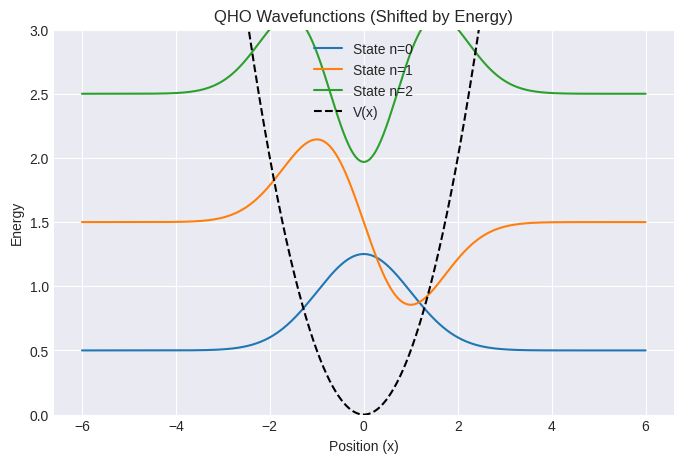

In [3]:
print("--- QUANTUM HARMONIC OSCILLATOR VERIFICATION ---")

# Setup: Domain must be wide enough for wavefunctions to decay to zero
qho_solver = FDMSolver(x_min=-6.0, x_max=6.0, N=2000)
qho_energies, qho_waves = qho_solver.solve(harmonic_oscillator, num_states=5)

for n in range(5):
    exact_E = n + 0.5
    calc_E = qho_energies[n]
    error_pct = abs(calc_E - exact_E) / exact_E * 100
    print(f"State n={n} | Exact: {exact_E:.4f} | Calc: {calc_E:.6f} | Error: {error_pct:.4f}%")

# Plotting the first 3 wavefunctions
plt.figure(figsize=(8, 5))
for n in range(3):
    plt.plot(qho_solver.x, qho_waves[n] + qho_energies[n], label=f'State n={n}')
plt.plot(qho_solver.x, harmonic_oscillator(qho_solver.x), 'k--', label='V(x)')
plt.ylim(0, 3)
plt.title("QHO Wavefunctions (Shifted by Energy)")
plt.xlabel("Position (x)")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [4]:
print("\n--- INFINITE SQUARE WELL VERIFICATION ---")

# Setup the precise geometry
N = 2000
L = 2.0
dx = L / (N + 1)

# Shift the grid so the implicit zeros land EXACTLY at -1.0 and 1.0
x_min = -1.0 + dx
x_max = 1.0 - dx

well_solver = FDMSolver(x_min=x_min, x_max=x_max, N=N)
well_energies, well_waves = well_solver.solve(square_well, num_states=5)

for n in range(1, 6):
    exact_E = (n**2 * np.pi**2) / (2 * L**2)
    calc_E = well_energies[n-1]
    error_pct = abs(calc_E - exact_E) / exact_E * 100
    print(f"State n={n} | Exact: {exact_E:.4f} | Calc: {calc_E:.6f} | Error: {error_pct:.4f}%")


--- INFINITE SQUARE WELL VERIFICATION ---
State n=1 | Exact: 1.2337 | Calc: 1.233700 | Error: 0.0000%
State n=2 | Exact: 4.9348 | Calc: 4.934798 | Error: 0.0001%
State n=3 | Exact: 11.1033 | Calc: 11.103284 | Error: 0.0002%
State n=4 | Exact: 19.7392 | Calc: 19.739144 | Error: 0.0003%
State n=5 | Exact: 30.8425 | Calc: 30.842355 | Error: 0.0005%


In [5]:
from solver import ShootingSolver

print("\n--- SHOOTING METHOD VERIFICATION (HARMONIC OSCILLATOR) ---")

# Initialize the Shooting Method solver
shoot_solver = ShootingSolver(-6.0, 6.0)

# We provide a bracket where we expect the ground state to be (e.g., between E=0.1 and E=0.9)
energies, _, _ = shoot_solver.solve(harmonic_oscillator, [(0.1, 0.9)])

exact_E = 0.5
calc_E = energies[0]
error_pct = abs(calc_E - exact_E) / exact_E * 100

print(f"Ground State (n=0) | Exact: {exact_E:.4f} | Calc: {calc_E:.6f} | Error: {error_pct:.4f}%")


--- SHOOTING METHOD VERIFICATION (HARMONIC OSCILLATOR) ---
Ground State (n=0) | Exact: 0.5000 | Calc: 0.500000 | Error: 0.0000%


In [6]:
print("\n--- SHOOTING METHOD VERIFICATION (INFINITE SQUARE WELL) ---")

# The boundaries for our square well are -1.0 to 1.0 (L=2.0)
well_shoot_solver = ShootingSolver(-1.0, 1.0)

# We know the ground state is around E = 1.23, so we bracket between 1.0 and 1.5
energies_well, _, _ = well_shoot_solver.solve(square_well, [(1.0, 1.5)])

exact_E_well = (1**2 * np.pi**2) / (2 * 2.0**2)  # n=1, L=2.0
calc_E_well = energies_well[0]
error_pct_well = abs(calc_E_well - exact_E_well) / exact_E_well * 100

print(f"Ground State (n=1) | Exact: {exact_E_well:.4f} | Calc: {calc_E_well:.6f} | Error: {error_pct_well:.4f}%")


--- SHOOTING METHOD VERIFICATION (INFINITE SQUARE WELL) ---
Ground State (n=1) | Exact: 1.2337 | Calc: 1.233700 | Error: 0.0000%
